# Task Info

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install mysql-connector-python

In [3]:
import mysql.connector

In [4]:
connection = mysql.connector.connect(
    host="localhost",
    user="air_user",
    password="root",
    database="air_quality_db"
)

print("MySQL Connected Successfully!")

MySQL Connected Successfully!


In [5]:
print(connection.is_connected())

True


# Modeling

In [6]:
import pandas as pd
import mysql.connector

In [7]:
connection = mysql.connector.connect(
    host="localhost",
    user="air_user",
    password="root",
    database="air_quality_db"
)

print("MySQL Connected Successfully!")

MySQL Connected Successfully!


In [8]:
query = "SELECT * FROM air_quality"

df = pd.read_sql(query, connection)

print("Data loaded successfully!")

Data loaded successfully!


C:\Users\P.MANISH KUMAR\AppData\Local\Temp\ipykernel_21536\1552463533.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [9]:
print(df.head())

  country           state           city  \
0   India  Andhra Pradesh       Kakinada   
1   India  Andhra Pradesh        Kurnool   
2   India  Andhra Pradesh        Kurnool   
3   India  Andhra Pradesh  Machilipatnam   
4   India  Andhra Pradesh  Machilipatnam   

                                        station       last_update   latitude  \
0               Rama Rao Peta, Kakinada - APPCB  25-08-2026 17.00  16.962488   
1              Sita Rama Nagar, Kurnool - APPCB  25-08-2026 17.00  15.834110   
2              Sita Rama Nagar, Kurnool - APPCB  25-08-2026 17.00  15.834110   
3  Srinivas Nagar Colony, Machilipatnam - APPCB  25-08-2026 17.00  16.186555   
4  Srinivas Nagar Colony, Machilipatnam - APPCB  25-08-2026 17.00  16.186555   

   longitude pollutant_id  pollutant_min  pollutant_max  pollutant_avg  
0  82.229513          NO2           27.0           51.0           39.0  
1  78.028546         PM10           28.0           47.0           38.0  
2  78.028546          NH3          

In [10]:
print(df.columns.tolist())

['country', 'state', 'city', 'station', 'last_update', 'latitude', 'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max', 'pollutant_avg']


In [11]:
y = df['pollutant_avg']

print("Target variable (y):")
print(y.head())

Target variable (y):
0    39.0
1    38.0
2     6.0
3    55.0
4     4.0
Name: pollutant_avg, dtype: float64


In [12]:
X = df.drop('pollutant_avg', axis=1)

print("Feature variables (X):")
print(X.head())

Feature variables (X):
  country           state           city  \
0   India  Andhra Pradesh       Kakinada   
1   India  Andhra Pradesh        Kurnool   
2   India  Andhra Pradesh        Kurnool   
3   India  Andhra Pradesh  Machilipatnam   
4   India  Andhra Pradesh  Machilipatnam   

                                        station       last_update   latitude  \
0               Rama Rao Peta, Kakinada - APPCB  25-08-2026 17.00  16.962488   
1              Sita Rama Nagar, Kurnool - APPCB  25-08-2026 17.00  15.834110   
2              Sita Rama Nagar, Kurnool - APPCB  25-08-2026 17.00  15.834110   
3  Srinivas Nagar Colony, Machilipatnam - APPCB  25-08-2026 17.00  16.186555   
4  Srinivas Nagar Colony, Machilipatnam - APPCB  25-08-2026 17.00  16.186555   

   longitude pollutant_id  pollutant_min  pollutant_max  
0  82.229513          NO2           27.0           51.0  
1  78.028546         PM10           28.0           47.0  
2  78.028546          NH3            6.0            6.0  

In [13]:
print("Missing values:")
print(X.isnull().sum())

Missing values:
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    330
pollutant_max    330
dtype: int64


In [14]:
X = X.copy()

X['last_update'] = pd.to_datetime(
    X['last_update'],
    errors='coerce',
    dayfirst=True
)

X['year'] = X['last_update'].dt.year
X['month'] = X['last_update'].dt.month
X['day'] = X['last_update'].dt.day
X['hour'] = X['last_update'].dt.hour

X = X.drop('last_update', axis=1)

print(X.head())

  country           state           city  \
0   India  Andhra Pradesh       Kakinada   
1   India  Andhra Pradesh        Kurnool   
2   India  Andhra Pradesh        Kurnool   
3   India  Andhra Pradesh  Machilipatnam   
4   India  Andhra Pradesh  Machilipatnam   

                                        station   latitude  longitude  \
0               Rama Rao Peta, Kakinada - APPCB  16.962488  82.229513   
1              Sita Rama Nagar, Kurnool - APPCB  15.834110  78.028546   
2              Sita Rama Nagar, Kurnool - APPCB  15.834110  78.028546   
3  Srinivas Nagar Colony, Machilipatnam - APPCB  16.186555  81.132190   
4  Srinivas Nagar Colony, Machilipatnam - APPCB  16.186555  81.132190   

  pollutant_id  pollutant_min  pollutant_max  year  month  day  hour  
0          NO2           27.0           51.0   NaN    NaN  NaN   NaN  
1         PM10           28.0           47.0   NaN    NaN  NaN   NaN  
2          NH3            6.0            6.0   NaN    NaN  NaN   NaN  
3         PM

In [15]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    'country',
    'state',
    'city',
    'station',
    'pollutant_id'
]

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("Categorical columns encoded successfully!")
print(X.head())

Categorical columns encoded successfully!
   country  state  city  station   latitude  longitude  pollutant_id  \
0        0      0   131      362  16.962488  82.229513             2   
1        0      0   153      450  15.834110  78.028546             4   
2        0      0   153      450  15.834110  78.028546             1   
3        0      0   158      456  16.186555  81.132190             4   
4        0      0   158      456  16.186555  81.132190             1   

   pollutant_min  pollutant_max  year  month  day  hour  
0           27.0           51.0   NaN    NaN  NaN   NaN  
1           28.0           47.0   NaN    NaN  NaN   NaN  
2            6.0            6.0   NaN    NaN  NaN   NaN  
3           52.0           64.0   NaN    NaN  NaN   NaN  
4            2.0            4.0   NaN    NaN  NaN   NaN  


In [16]:
print(X.dtypes)

country            int64
state              int64
city               int64
station            int64
latitude         float64
longitude        float64
pollutant_id       int64
pollutant_min    float64
pollutant_max    float64
year             float64
month            float64
day              float64
hour             float64
dtype: object


In [17]:
print("Missing values before handling:")
print(X.isnull().sum())

X = X.fillna(X.median(numeric_only=True))

print("\nMissing values after handling:")
print(X.isnull().sum())

Missing values before handling:
country             0
state               0
city                0
station             0
latitude            0
longitude           0
pollutant_id        0
pollutant_min     330
pollutant_max     330
year             3549
month            3549
day              3549
hour             3549
dtype: int64

Missing values after handling:
country             0
state               0
city                0
station             0
latitude            0
longitude           0
pollutant_id        0
pollutant_min       0
pollutant_max       0
year             3549
month            3549
day              3549
hour             3549
dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Training data shape: (2839, 13)
Testing data shape: (710, 13)

X_train: (2839, 13)
X_test: (710, 13)
y_train: (2839,)
y_test: (710,)


In [19]:
print("NaN values in X:")
print(X.isnull().sum())

print("\nTotal NaN values:", X.isnull().sum().sum())

NaN values in X:
country             0
state               0
city                0
station             0
latitude            0
longitude           0
pollutant_id        0
pollutant_min       0
pollutant_max       0
year             3549
month            3549
day              3549
hour             3549
dtype: int64

Total NaN values: 14196


In [20]:
X = X.dropna(axis=1, how='all')

print("Remaining columns:")
print(X.columns.tolist())

Remaining columns:
['country', 'state', 'city', 'station', 'latitude', 'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max']


In [21]:
from sklearn.impute import SimpleImputer
import pandas as pd

imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Missing values after imputation:")
print(X_imputed.isnull().sum())

Missing values after imputation:
country          0
state            0
city             0
station          0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2839, 9)
X_test shape: (710, 9)


In [23]:
print("Missing values in y:", y.isnull().sum())

Missing values in y: 330


In [24]:
data = X_imputed.copy()

data['pollutant_avg'] = y

data = data.dropna(subset=['pollutant_avg'])

print("Dataset shape after removing missing target values:", data.shape)

Dataset shape after removing missing target values: (3219, 10)


In [25]:
X_clean = data.drop('pollutant_avg', axis=1)

y_clean = data['pollutant_avg']

print("X_clean shape:", X_clean.shape)
print("y_clean shape:", y_clean.shape)

print("Missing values in X:", X_clean.isnull().sum().sum())
print("Missing values in y:", y_clean.isnull().sum())

X_clean shape: (3219, 9)
y_clean shape: (3219,)
Missing values in X: 0
Missing values in y: 0


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2575, 9)
X_test: (644, 9)
y_train: (2575,)
y_test: (644,)


In [27]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [28]:
y_pred_lr = lr_model.predict(X_test)

print("Predictions completed successfully!")

print(y_pred_lr[:10])

Predictions completed successfully!
[67.05989318  6.7533122  23.41722372  0.08060518 21.30168726  5.80503035
 16.27828221 24.11599962  6.69178954 44.62554423]


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

Linear Regression Performance
-----------------------------
MAE: 3.6402075136488077
MSE: 67.90534019428374
RMSE: 8.240469658598576
R² Score: 0.905810375542839


In [30]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_lr
})

comparison.head(10)

,Actual,Predicted
0,64.0,67.059893
1,5.0,6.753312
2,26.0,23.417224
3,0.0,0.080605
4,21.0,21.301687
5,6.0,5.805030
6,18.0,16.278282
7,23.0,24.116000
8,6.0,6.691790
9,42.0,44.625544


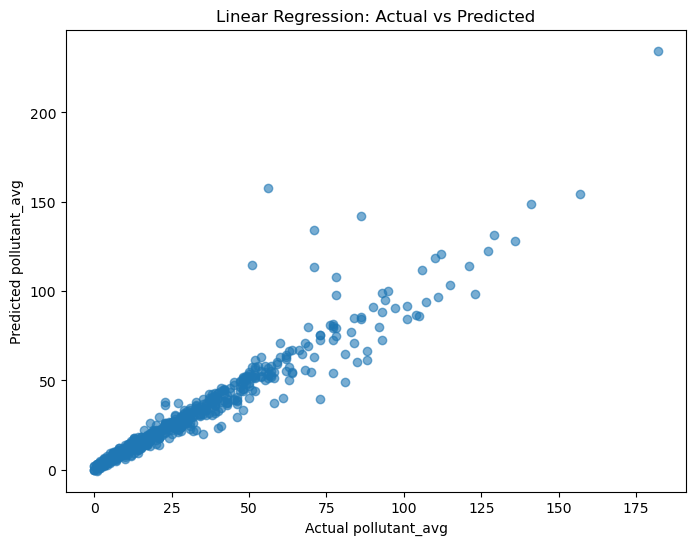

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.xlabel("Actual pollutant_avg")
plt.ylabel("Predicted pollutant_avg")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()